In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import gsw
import colormaps as cmaps
import matplotlib.colors as mcolors
from tqdm import tqdm

In [2]:
ww_core_depth = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/ww_core_depth.nc').depth

Computing pre-2016 MK trend...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipyker

  slope range : -6.68067 – 8.25861 g/kg/yr
  sig frac    : 2.5%
Computing post-2016 MK trend...


/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2194109497.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykern

  slope range : -18.24906 – 11.99665 g/kg/yr
  sig frac    : 2.1%


/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/tmp/ipykernel_307533/2194109497.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


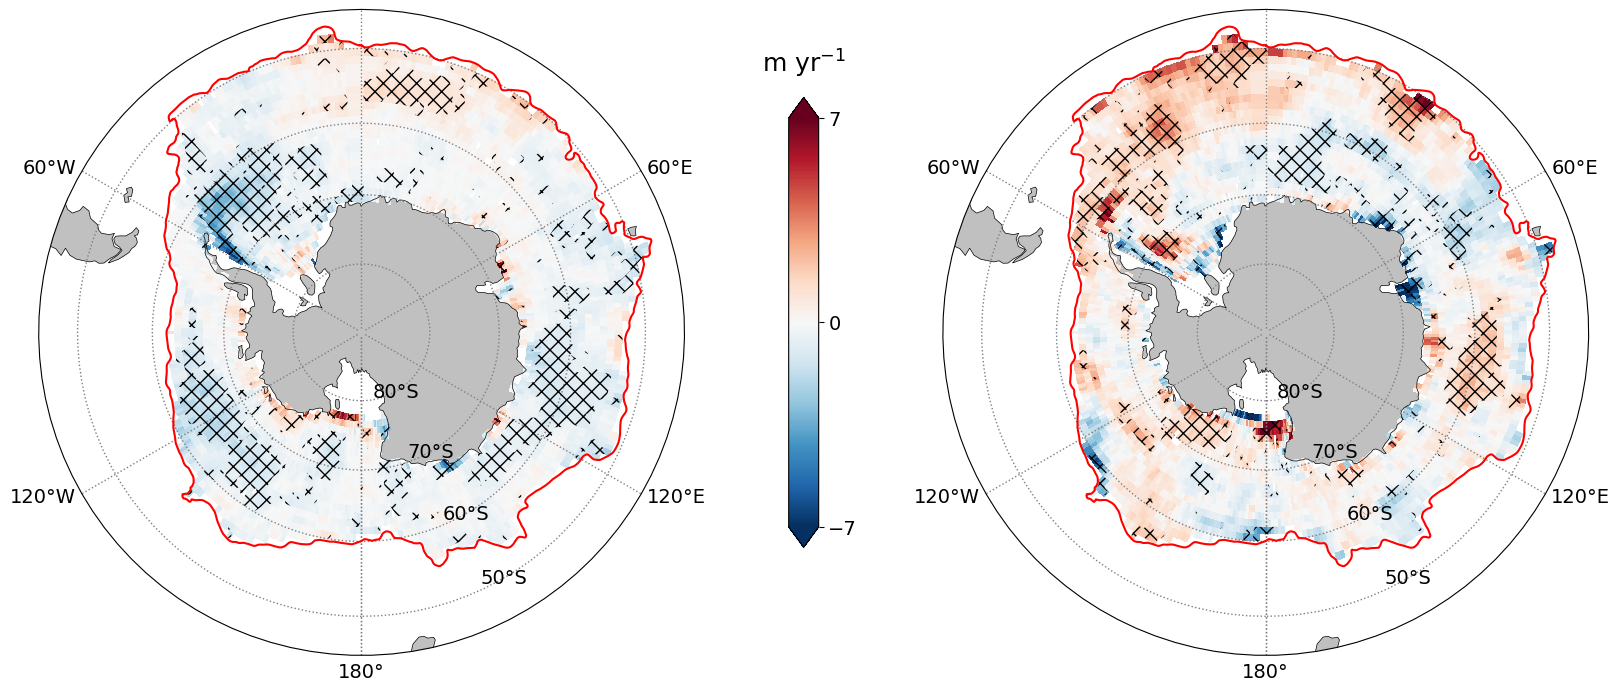

In [3]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeLocator, LatitudeLocator
import pymannkendall as mk
import warnings
from joblib import Parallel, delayed
from scipy.interpolate import interp1d

# ============================================================
# POLAR FRONT
# ============================================================
pf_lats        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF
pf_lons_wrapped = np.mod(pf_lons, 360)

# ============================================================
# MK SPATIAL TREND — parallel over latitude rows
# Deseasonalizes monthly data then applies Hamed-Rao MK
# ============================================================
def process_row_mk(j, data_row, min_valid=30):
    """
    data_row : (nt, nlon) monthly raw data
    Returns  : slope_row (nlon,) per year, sig_row (nlon,)
    """
    nt, nlon  = data_row.shape
    slope_row = np.full(nlon, np.nan)
    sig_row   = np.full(nlon, np.nan)

    # Monthly climatology for this row
    clim = np.array([
        np.nanmean(data_row[m::12, k])
        for m in range(12)
        for k in range(nlon)
    ]).reshape(12, nlon)

    # Anomaly
    anom = data_row.copy().astype(float)
    for t in range(nt):
        anom[t] = data_row[t] - clim[t % 12]

    for k in range(nlon):
        v     = anom[:, k]
        valid = np.isfinite(v)
        v_v   = v[valid]
        if len(v_v) < min_valid:
            continue
        if np.std(v_v) < 1e-10:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                result = mk.hamed_rao_modification_test(v_v)
            if np.isnan(result.slope) or np.isnan(result.p):
                continue
            slope_row[k] = result.slope * 12   # per year
            if result.p < 0.05:
                sig_row[k] = 1
        except Exception:
            continue

    return j, slope_row, sig_row

def mk_spatial_trend_parallel(data_3d, min_valid=30, n_jobs=-1):
    nt, nlat, nlon = data_3d.shape
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(process_row_mk)(j, data_3d[:, j, :], min_valid)
        for j in range(nlat)
    )
    slope_arr = np.full((nlat, nlon), np.nan)
    sig_arr   = np.full((nlat, nlon), np.nan)
    for j, slope_row, sig_row in results:
        slope_arr[j] = slope_row
        sig_arr[j]   = sig_row
    return slope_arr, sig_arr

# ============================================================
# PRE-2016 : indices 0:144
# ============================================================
print("Computing pre-2016 MK trend...")
data_pre           = ww_core_depth[0:144, :, :].values
nlat, nlon         = data_pre.shape[1], data_pre.shape[2]

slope_pre, sig_pre = mk_spatial_trend_parallel(
    data_pre, min_valid=30, n_jobs=-1)

slope_pre_xr = xr.DataArray(slope_pre,
    coords={'lat': ww_core_depth.lat, 'lon': ww_core_depth.lon},
    dims=['lat','lon'])
sig_pre_xr   = xr.DataArray(sig_pre,
    coords={'lat': ww_core_depth.lat, 'lon': ww_core_depth.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_pre):.5f} – "
      f"{np.nanmax(slope_pre):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_pre))*100:.1f}%")

# ============================================================
# POST-2016 : indices 144:240
# ============================================================
print("Computing post-2016 MK trend...")
data_post              = ww_core_depth[144:240, :, :].values

slope_post, sig_post   = mk_spatial_trend_parallel(
    data_post, min_valid=24, n_jobs=-1)

slope_post_xr = xr.DataArray(slope_post,
    coords={'lat': ww_core_depth.lat, 'lon': ww_core_depth.lon},
    dims=['lat','lon'])
sig_post_xr   = xr.DataArray(sig_post,
    coords={'lat': ww_core_depth.lat, 'lon': ww_core_depth.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_post):.5f} – "
      f"{np.nanmax(slope_post):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_post))*100:.1f}%")

# ============================================================
# LON WRAPPING
# ============================================================
lon      = ww_core_depth['lon'].values
lat      = ww_core_depth['lat'].values
lon_fixed = np.append(lon, lon[0] + 360)

def wrap_numpy(arr):
    f          = np.array(arr, dtype=float).copy()
    f[:, -3:]  = f[:, -4:-3]
    f[:,  0:3] = f[:,  2:3]
    return np.hstack([f, f[:, 0:1]])

# ============================================================
# PLOT
# ============================================================
def polarCentral_set_latlim(lat_lims, ax):
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]],
                  ccrs.PlateCarree())
    theta  = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 10),
    subplot_kw={'projection': ccrs.SouthPolarStereo(
        central_longitude=0)},
    gridspec_kw={'wspace': 0.4}
)

for ax in [ax1, ax2]:
    ax.add_feature(cfeature.LAND, facecolor='silver')
    ax.coastlines(linewidth=0.5, color='k')
    polarCentral_set_latlim((-90, -45), ax)
    gl = ax.gridlines(
        color='C7', lw=1, ls=':', draw_labels=True,
        rotate_labels=False,
        ylocs=[-80, -70, -60, -50, -40, -30],
        xlocs=[-180, -120, -60, 0, 60, 120, 180]
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator     = LongitudeLocator(dms=False)
    gl.ylocator     = LatitudeLocator(dms=False)

# ── Pre-2016 ──
filler1     = wrap_numpy(slope_pre_xr.values)  # per year → already /yr
sig1        = wrap_numpy(np.where(~np.isnan(sig_pre), 1.0, np.nan))

cs1 = ax1.pcolormesh(
    lon_fixed, lat, filler1,
    cmap='RdBu_r', vmin=-7, vmax=7,
    transform=ccrs.PlateCarree(), zorder=1
)
ax1.contourf(
    lon_fixed, lat, np.nan_to_num(sig1, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax1.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax1)
# ax1.set_title('Pre-2016 (2004–2015)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Post-2016 ──
filler2     = wrap_numpy(slope_post_xr.values)
sig2        = wrap_numpy(np.where(~np.isnan(sig_post), 1.0, np.nan))

cs2 = ax2.pcolormesh(
    lon_fixed, lat, filler2,
    cmap='RdBu_r', vmin=-7, vmax=7,
    transform=ccrs.PlateCarree(), zorder=1
)
ax2.contourf(
    lon_fixed, lat, np.nan_to_num(sig2, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax2.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax2)
# ax2.set_title('Post-2016 (2016–2023)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Colorbar ──
cbar_ax = fig.add_axes([0.50, 0.28, 0.015, 0.45])
cbar    = fig.colorbar(
    cs1, cax=cbar_ax,
    orientation='vertical',
    extend='both',
    ticks=[-7, 0, 7]
)
cbar.ax.set_title(r'm yr$^{-1}$', fontsize=18, pad=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/'
#     'WW_salt_ensemble_trend_pre_post.jpg',
#     bbox_inches='tight', dpi=500)
# plt.show()

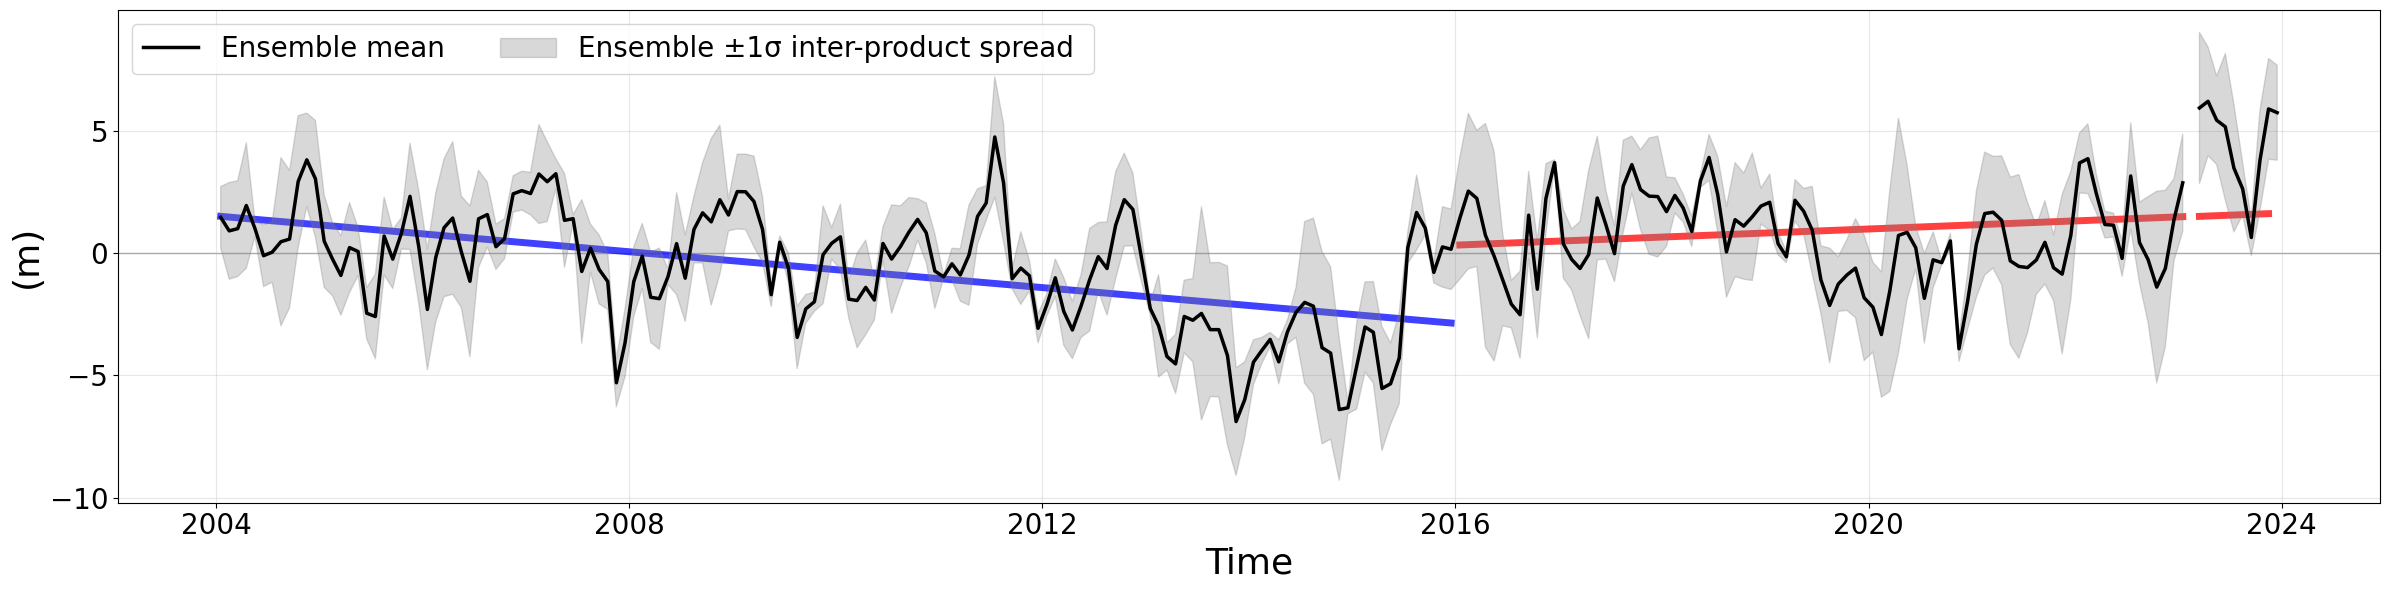

In [5]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD SAVED RESULTS
# ============================================================
ds_ens = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/final_nc_files/WW_depth_ensemble.nc')

time            = pd.to_datetime(ds_ens['time'].values)
ens_mean        = ds_ens['ens_mean']
ens_spatial_std = ds_ens['ens_spatial_std'].values
tr_ens_pre      = ds_ens['tr_ens_pre'].values
tr_ens_post     = ds_ens['tr_ens_post'].values

s_ens_pre   = float(ds_ens['s_ens_pre'])
se_ens_pre  = float(ds_ens['se_ens_pre'])
p_ens_pre   = float(ds_ens['p_ens_pre'])
s_ens_post  = float(ds_ens['s_ens_post'])
se_ens_post = float(ds_ens['se_ens_post'])
p_ens_post  = float(ds_ens['p_ens_post'])


# ============================================================
# PLOT (unchanged from your original)
# ============================================================
fig, ax = plt.subplots(figsize=(24, 6))

# ── Ensemble mean + RSS spatial std ──
ax.plot(time, ens_mean.values, color='black', lw=2.5, zorder=5,
        label='Ensemble mean')
ax.fill_between(time,
                ens_mean.values - ens_spatial_std,
                ens_mean.values + ens_spatial_std,
                color='grey', alpha=0.3, zorder=4,
                label=f'Ensemble ±1σ inter-product spread ')

# ── Trend lines — ensemble ──
ax.plot(time, tr_ens_pre,
        color='blue',  ls='-', alpha=0.75, lw=5, zorder=3)
ax.plot(time, tr_ens_post,
        color='red', ls='-', alpha=0.75, lw=5, zorder=3)

# ── Reference lines ──
ax.axhline(0, color='darkgrey', lw=1, zorder=0)
# ax.axvline(pd.Timestamp('2016-01-01'), color='red',
#            lw=2, ls=':', zorder=7, label='2016 breakpoint')

ax.set_ylabel(r'(m)', fontsize=26)
ax.set_xlabel('Time', fontsize=26)
ax.legend(fontsize=20, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
# ax.set_yticks([-0.06, -0.03, 0, 0.03, 0.06])
# ax.set_ylim(-0.08,0.08)
ax.tick_params(labelsize=20)

plt.tight_layout()
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/'
#     'ENSEMBLE_MEANS/final_figure_nc_files/WW_depth_member_TS.jpg',
#     dpi=500, bbox_inches='tight')
plt.show()

In [6]:
ww_core_density = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/ww_sig0.nc').__xarray_dataarray_variable__

Computing pre-2016 MK trend...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 64 concurrent workers.
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipyker

  slope range : -0.01978 – 0.07644 g/kg/yr
  sig frac    : 2.9%
Computing post-2016 MK trend...


/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykernel_307533/2222135957.py:37: RuntimeWarning: Mean of empty slice
/tmp/ipykern

  slope range : -0.05393 – 0.03682 g/kg/yr
  sig frac    : 2.4%


/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/scratch/kaushik/anaconda3/envs/ocean_old/lib/python3.11/site-packages/shapely/creation.py:218: RuntimeWarning: invalid value encountered in linestrings
  return lib.linestrings(coords, np.intc(handle_nan), out=out, **kwargs)
/tmp/ipykernel_307533/2222135957.py:225: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


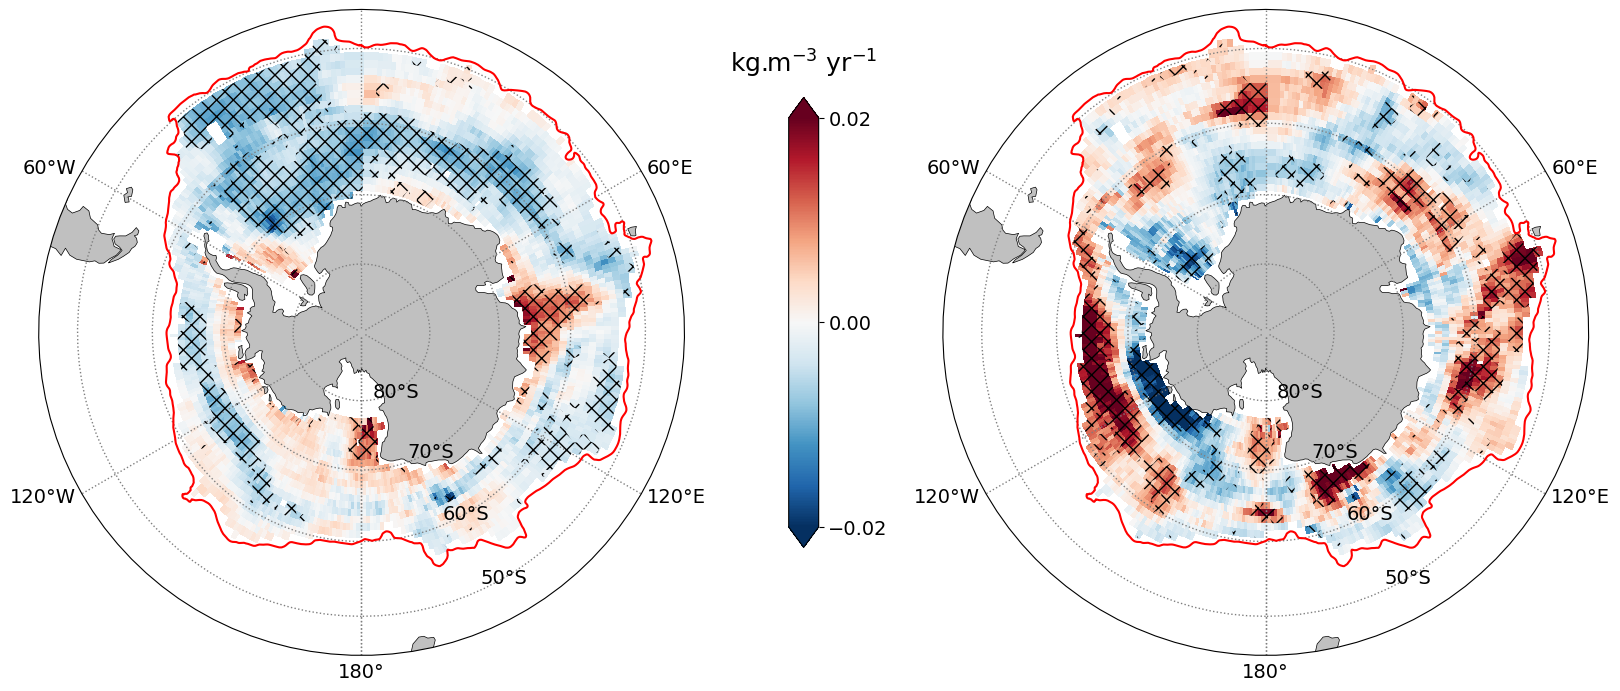

In [8]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.path as mpath
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeLocator, LatitudeLocator
import pymannkendall as mk
import warnings
from joblib import Parallel, delayed
from scipy.interpolate import interp1d

# ============================================================
# POLAR FRONT
# ============================================================
pf_lats        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LatPF
pf_lons        = xr.open_dataset(
    '/scratch/kaushik/WORK/INTERMEDIATE_WATER/ACC_fronts/62985.nc').LonPF
pf_lons_wrapped = np.mod(pf_lons, 360)

# ============================================================
# MK SPATIAL TREND — parallel over latitude rows
# Deseasonalizes monthly data then applies Hamed-Rao MK
# ============================================================
def process_row_mk(j, data_row, min_valid=30):
    """
    data_row : (nt, nlon) monthly raw data
    Returns  : slope_row (nlon,) per year, sig_row (nlon,)
    """
    nt, nlon  = data_row.shape
    slope_row = np.full(nlon, np.nan)
    sig_row   = np.full(nlon, np.nan)

    # Monthly climatology for this row
    clim = np.array([
        np.nanmean(data_row[m::12, k])
        for m in range(12)
        for k in range(nlon)
    ]).reshape(12, nlon)

    # Anomaly
    anom = data_row.copy().astype(float)
    for t in range(nt):
        anom[t] = data_row[t] - clim[t % 12]

    for k in range(nlon):
        v     = anom[:, k]
        valid = np.isfinite(v)
        v_v   = v[valid]
        if len(v_v) < min_valid:
            continue
        if np.std(v_v) < 1e-10:
            continue
        try:
            with warnings.catch_warnings():
                warnings.simplefilter('ignore')
                result = mk.hamed_rao_modification_test(v_v)
            if np.isnan(result.slope) or np.isnan(result.p):
                continue
            slope_row[k] = result.slope * 12   # per year
            if result.p < 0.05:
                sig_row[k] = 1
        except Exception:
            continue

    return j, slope_row, sig_row

def mk_spatial_trend_parallel(data_3d, min_valid=30, n_jobs=-1):
    nt, nlat, nlon = data_3d.shape
    results = Parallel(n_jobs=n_jobs, verbose=5)(
        delayed(process_row_mk)(j, data_3d[:, j, :], min_valid)
        for j in range(nlat)
    )
    slope_arr = np.full((nlat, nlon), np.nan)
    sig_arr   = np.full((nlat, nlon), np.nan)
    for j, slope_row, sig_row in results:
        slope_arr[j] = slope_row
        sig_arr[j]   = sig_row
    return slope_arr, sig_arr

# ============================================================
# PRE-2016 : indices 0:144
# ============================================================
print("Computing pre-2016 MK trend...")
data_pre           = ww_core_density[0:144, :, :].values
nlat, nlon         = data_pre.shape[1], data_pre.shape[2]

slope_pre, sig_pre = mk_spatial_trend_parallel(
    data_pre, min_valid=30, n_jobs=-1)

slope_pre_xr = xr.DataArray(slope_pre,
    coords={'lat': ww_core_density.lat, 'lon': ww_core_density.lon},
    dims=['lat','lon'])
sig_pre_xr   = xr.DataArray(sig_pre,
    coords={'lat': ww_core_density.lat, 'lon': ww_core_density.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_pre):.5f} – "
      f"{np.nanmax(slope_pre):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_pre))*100:.1f}%")

# ============================================================
# POST-2016 : indices 144:240
# ============================================================
print("Computing post-2016 MK trend...")
data_post              = ww_core_density[144:240, :, :].values

slope_post, sig_post   = mk_spatial_trend_parallel(
    data_post, min_valid=24, n_jobs=-1)

slope_post_xr = xr.DataArray(slope_post,
    coords={'lat': ww_core_density.lat, 'lon': ww_core_density.lon},
    dims=['lat','lon'])
sig_post_xr   = xr.DataArray(sig_post,
    coords={'lat': ww_core_density.lat, 'lon': ww_core_density.lon},
    dims=['lat','lon'])

print(f"  slope range : {np.nanmin(slope_post):.5f} – "
      f"{np.nanmax(slope_post):.5f} g/kg/yr")
print(f"  sig frac    : "
      f"{np.nanmean(~np.isnan(sig_post))*100:.1f}%")

# ============================================================
# LON WRAPPING
# ============================================================
lon      = ww_core_density['lon'].values
lat      = ww_core_density['lat'].values
lon_fixed = np.append(lon, lon[0] + 360)

def wrap_numpy(arr):
    f          = np.array(arr, dtype=float).copy()
    f[:, -3:]  = f[:, -4:-3]
    f[:,  0:3] = f[:,  2:3]
    return np.hstack([f, f[:, 0:1]])

# ============================================================
# PLOT
# ============================================================
def polarCentral_set_latlim(lat_lims, ax):
    ax.set_extent([-180, 180, lat_lims[0], lat_lims[1]],
                  ccrs.PlateCarree())
    theta  = np.linspace(0, 2*np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts  = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

fig, (ax1, ax2) = plt.subplots(
    1, 2, figsize=(20, 10),
    subplot_kw={'projection': ccrs.SouthPolarStereo(
        central_longitude=0)},
    gridspec_kw={'wspace': 0.4}
)

for ax in [ax1, ax2]:
    ax.add_feature(cfeature.LAND, facecolor='silver')
    ax.coastlines(linewidth=0.5, color='k')
    polarCentral_set_latlim((-90, -45), ax)
    gl = ax.gridlines(
        color='C7', lw=1, ls=':', draw_labels=True,
        rotate_labels=False,
        ylocs=[-80, -70, -60, -50, -40, -30],
        xlocs=[-180, -120, -60, 0, 60, 120, 180]
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}
    gl.xlocator     = LongitudeLocator(dms=False)
    gl.ylocator     = LatitudeLocator(dms=False)

# ── Pre-2016 ──
filler1     = wrap_numpy(slope_pre_xr.values)  # per year → already /yr
sig1        = wrap_numpy(np.where(~np.isnan(sig_pre), 1.0, np.nan))

cs1 = ax1.pcolormesh(
    lon_fixed, lat, filler1,
    cmap='RdBu_r', vmin=-0.02, vmax=0.02,
    transform=ccrs.PlateCarree(), zorder=1
)
ax1.contourf(
    lon_fixed, lat, np.nan_to_num(sig1, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax1.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax1)
# ax1.set_title('Pre-2016 (2004–2015)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Post-2016 ──
filler2     = wrap_numpy(slope_post_xr.values)
sig2        = wrap_numpy(np.where(~np.isnan(sig_post), 1.0, np.nan))

cs2 = ax2.pcolormesh(
    lon_fixed, lat, filler2,
    cmap='RdBu_r', vmin=-0.02, vmax=0.02,
    transform=ccrs.PlateCarree(), zorder=1
)
ax2.contourf(
    lon_fixed, lat, np.nan_to_num(sig2, nan=0),
    hatches=['xx'], levels=[0.5, 1.5],
    alpha=0, transform=ccrs.PlateCarree(), zorder=5
)
ax2.plot(pf_lons_wrapped, pf_lats, color='red',
         linewidth=1.5, transform=ccrs.PlateCarree(), zorder=10)
polarCentral_set_latlim((-90, -45), ax2)
# ax2.set_title('Post-2016 (2016–2023)\nHamed-Rao MK Sen slope',
#               fontsize=16, pad=12)

# ── Colorbar ──
cbar_ax = fig.add_axes([0.50, 0.28, 0.015, 0.45])
cbar    = fig.colorbar(
    cs1, cax=cbar_ax,
    orientation='vertical',
    extend='both',
    ticks=[-0.02, 0, 0.02]
)
cbar.ax.set_title(r'kg.m$^{-3}$ yr$^{-1}$', fontsize=18, pad=18)
cbar.ax.tick_params(labelsize=14)

plt.tight_layout()
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/'
#     'WW_salt_ensemble_trend_pre_post.jpg',
#     bbox_inches='tight', dpi=500)
# plt.show()

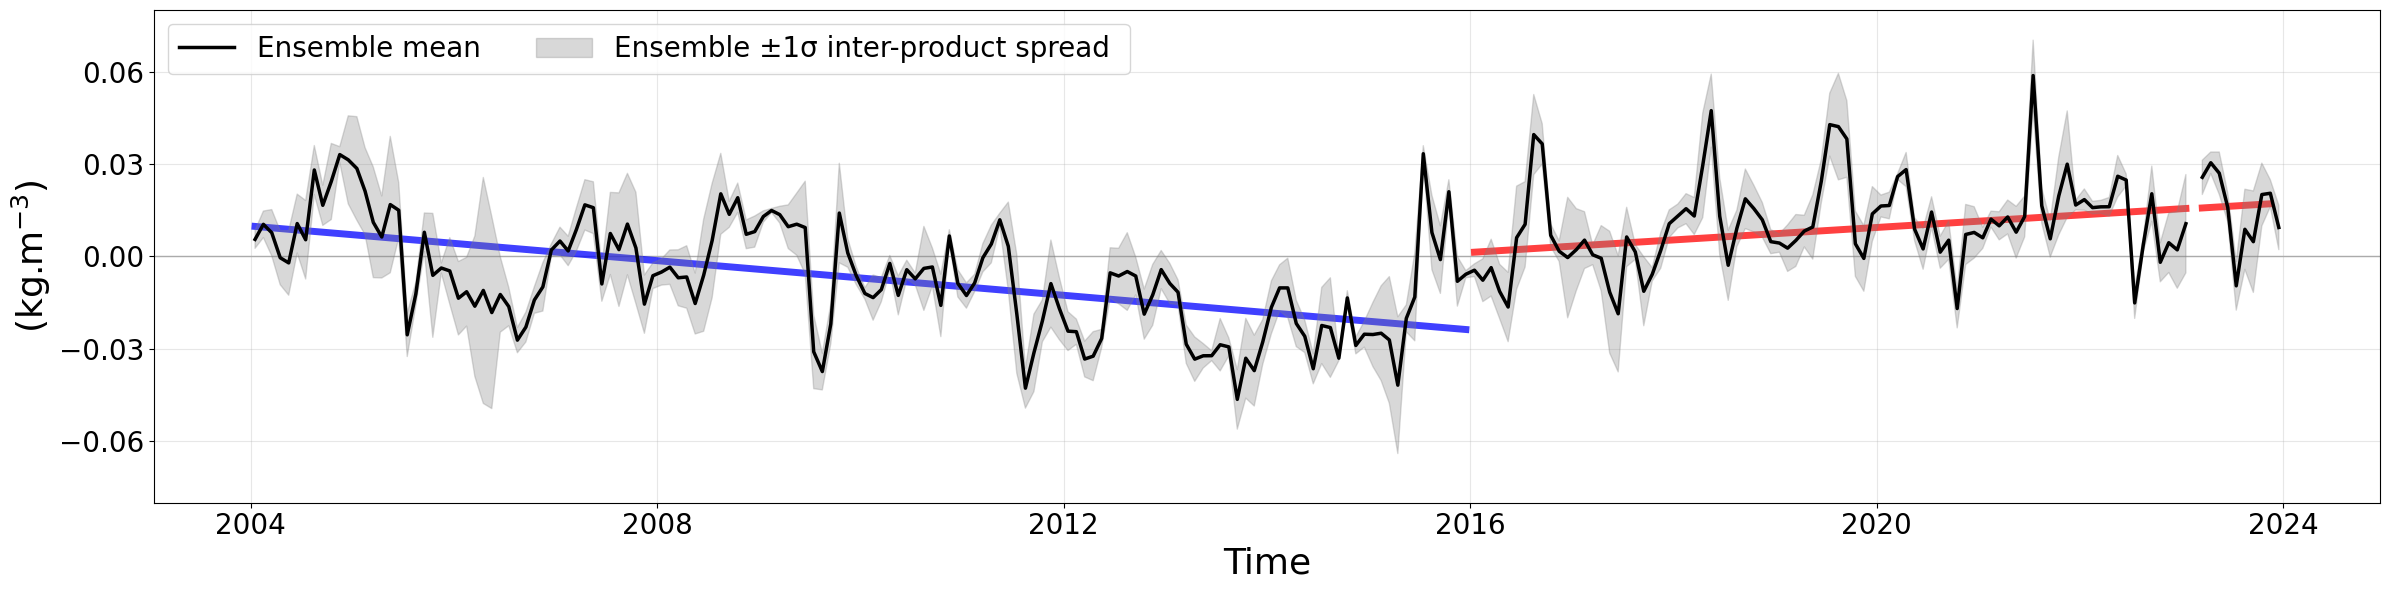

In [10]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# LOAD SAVED RESULTS
# ============================================================
ds_ens = xr.open_dataset('/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/ENSEMBLE_MEANS/final_figure_nc_files/final_nc_files/WW_dens_ensemble.nc')

time            = pd.to_datetime(ds_ens['time'].values)
ens_mean        = ds_ens['ens_mean']
ens_spatial_std = ds_ens['ens_spatial_std'].values
tr_ens_pre      = ds_ens['tr_ens_pre'].values
tr_ens_post     = ds_ens['tr_ens_post'].values

s_ens_pre   = float(ds_ens['s_ens_pre'])
cl_ens_pre  = float(ds_ens['cl_ens_pre'])
ch_ens_pre  = float(ds_ens['ch_ens_pre'])
p_ens_pre   = float(ds_ens['p_ens_pre'])
s_ens_post  = float(ds_ens['s_ens_post'])
cl_ens_post = float(ds_ens['cl_ens_post'])
ch_ens_post = float(ds_ens['ch_ens_post'])
p_ens_post  = float(ds_ens['p_ens_post'])


# ============================================================
# PLOT (unchanged from your original)
# ============================================================
fig, ax = plt.subplots(figsize=(24, 6))

# ── Ensemble mean + RSS spatial std ──
ax.plot(time, ens_mean.values, color='black', lw=2.5, zorder=5,
        label='Ensemble mean')
ax.fill_between(time,
                ens_mean.values - ens_spatial_std,
                ens_mean.values + ens_spatial_std,
                color='grey', alpha=0.3, zorder=4,
                label=f'Ensemble ±1σ inter-product spread ')

# ── Sen slope trend lines — ensemble ──
ax.plot(time, tr_ens_pre,
        color='blue',  ls='-', alpha=0.75, lw=5, zorder=3)
ax.plot(time, tr_ens_post,
        color='red', ls='-', alpha=0.75, lw=5, zorder=3)

# ── Reference lines ──
ax.axhline(0, color='darkgrey', lw=1, zorder=0)
# ax.axvline(pd.Timestamp('2016-01-01'), color='red',
#            lw=2, ls=':', zorder=7, label='2016 breakpoint')

ax.set_ylabel(r'(kg.m$^{-3}$)', fontsize=26)
ax.set_xlabel('Time', fontsize=26)
ax.legend(fontsize=20, loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)
ax.set_yticks([-0.06, -0.03, 0, 0.03, 0.06])
ax.set_ylim(-0.08, 0.08)
ax.tick_params(labelsize=20)

plt.tight_layout()
# plt.savefig(
#     '/scratch/kaushik/WORK/INTERMEDIATE_WATER/my_py_scripts/figures/'
#     'ENSEMBLE_MEANS/final_figure_nc_files/WW_dens_member_TS.jpg',
#     dpi=500, bbox_inches='tight')
plt.show()